# 05 v2 — Locomizer two-time footfall change + PM₂.₅ integration

## Purpose

This notebook extends the validated Locomizer footfall exploration into a simple **two-time comparison**.

It keeps the assumptions already established in Stage 01 of the Locomizer workflow:

- `CODE` is an H3 resolution-10 cell identifier;
- `TIME_INTERVAL = 0–23` are hourly observations;
- `TIME_INTERVAL = 25` stays excluded;
- `NUMBER_OF_USERS` is a **cell-level footfall / presence measure**, not a unique regional population count;
- missing cell-hours are **not** treated as zero;
- the Helsinki metropolitan area (Helsinki, Espoo, Vantaa, Kauniainen) remains the study area.

The first objective is deliberately narrow:

1. choose **Time A** and **Time B**;
2. compare footfall in the same H3 cells;
3. attach PM₂.₅ for both timestamps **when temporally matched PM₂.₅ rasters are available**;
4. calculate footfall change and PM₂.₅ change;
5. classify the observed pattern into simple response types.

## Important temporal warning

The `cafein.sampledata.helsinki.air_quality` raster used elsewhere in the CAFEIN examples is a **single model hour** and is **not a June 2023 hourly series**. This notebook therefore does **not** silently use that raster for the June 2023 Locomizer observations.

Set `PM25_A_PATH` and `PM25_B_PATH` only when you have PM₂.₅ rasters corresponding to the selected timestamps.


## 1. Imports and configuration

In [1]:
from pathlib import Path

import h3
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import rasterio
from shapely.geometry import Polygon

# -------------------------------------------------------------------
# Existing clean Locomizer checkpoint created by the exploration notebook
# -------------------------------------------------------------------
DERIVED_DIR = Path(
    "/scratch/project_2010417/paper3/locomizer/derived"
)

FOOTFALL_PARQUET = (
    DERIVED_DIR
    / "helsinki_footfall_hourly_exploratory_2023-06-10_20.parquet"
)

BOUNDARY_CACHE = (
    DERIVED_DIR
    / "helsinki_metropolitan_area_boundary.gpkg"
)

# -------------------------------------------------------------------
# Two-time proof-of-concept
# -------------------------------------------------------------------
# Time B keeps the target already used in the Locomizer exploration.
TIME_B_DATE = pd.Timestamp("2023-06-18")
TIME_B_HOUR = 12

# Time A is an explicit comparison snapshot.
# Change this date if you want another clean/reference example.
TIME_A_DATE = pd.Timestamp("2023-06-17")
TIME_A_HOUR = 12

# -------------------------------------------------------------------
# Optional temporally matched PM2.5 rasters
# -------------------------------------------------------------------
# Leave these as None until you have PM2.5 rasters for the two selected times.
PM25_A_PATH = None
PM25_B_PATH = None

# If your PM2.5 GeoTIFF is multi-band, set the relevant 1-based band number.
PM25_A_BAND = 1
PM25_B_BAND = 1

OUTPUT_DIR = Path("../outputs/v2/05_locomizer_two_time_pm25_change")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Time A:", TIME_A_DATE.date(), f"{TIME_A_HOUR:02d}:00")
print("Time B:", TIME_B_DATE.date(), f"{TIME_B_HOUR:02d}:00")
print("Output:", OUTPUT_DIR.resolve())


Time A: 2023-06-17 12:00
Time B: 2023-06-18 12:00
Output: /scratch/project_2010417/paper3/airqualityontario22-25/cafein-helsinki-exposure-poc/outputs/v2/05_locomizer_two_time_pm25_change


## 2. Load the validated Locomizer checkpoint

In [2]:
if not FOOTFALL_PARQUET.exists():
    raise FileNotFoundError(
        f"{FOOTFALL_PARQUET} was not found. "
        "Run 01_locomizer_footfall_exploration_clean first."
    )

footfall = pd.read_parquet(FOOTFALL_PARQUET)

required = {
    "CODE",
    "date",
    "TIME_INTERVAL",
    "NUMBER_OF_USERS",
}

missing = required.difference(footfall.columns)

if missing:
    raise ValueError(
        f"Missing expected columns in Locomizer checkpoint: {sorted(missing)}"
    )

footfall["date"] = pd.to_datetime(footfall["date"])

print("Rows:", len(footfall))
print("Dates:", footfall["date"].min().date(), "to", footfall["date"].max().date())
print("H3 cells:", footfall["CODE"].nunique())
print("Hours:", sorted(footfall["TIME_INTERVAL"].dropna().unique())[:30])


Rows: 1420486
Dates: 2023-06-10 to 2023-06-20
H3 cells: 17312
Hours: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23)]


## 3. Load the HMA boundary

In [3]:
if not BOUNDARY_CACHE.exists():
    raise FileNotFoundError(
        f"{BOUNDARY_CACHE} was not found. "
        "Run the Locomizer exploration notebook first so the HMA boundary is cached."
    )

hma_boundary = gpd.read_file(BOUNDARY_CACHE).to_crs("EPSG:4326")
hma_boundary


,bbox_west,bbox_south,bbox_east,bbox_north,place_id,osm_type,osm_id,lat,lon,class,type,place_rank,importance,addresstype,name,display_name,geometry
0,24.782803,59.922486,25.254512,60.29785,167666314,relation,34914,60.16662,24.943541,boundary,administrative,15,0.797091,city,Helsinki,"Helsinki, Helsinki sub-region, Uusimaa, Mainla...","POLYGON ((25.19026 60.28567, 25.19187 60.28468..."


## 4. Extract Time A and Time B

Only H3 cells observed at each selected timestamp are retained.

The comparison uses the **intersection** of cells present at both timestamps so that a missing observation is not interpreted as zero activity.


In [4]:
time_a = footfall.loc[
    (footfall["date"] == TIME_A_DATE)
    & (footfall["TIME_INTERVAL"] == TIME_A_HOUR)
].copy()

time_b = footfall.loc[
    (footfall["date"] == TIME_B_DATE)
    & (footfall["TIME_INTERVAL"] == TIME_B_HOUR)
].copy()

print("Time A rows:", len(time_a))
print("Time B rows:", len(time_b))

if time_a.empty:
    raise ValueError("No Locomizer observations found for Time A.")

if time_b.empty:
    raise ValueError("No Locomizer observations found for Time B.")


Time A rows: 6883
Time B rows: 6338


## 5. Build H3 polygons and merge the two snapshots

In [5]:
def h3_to_polygon(cell):
    boundary = h3.cell_to_boundary(str(cell))
    return Polygon(
        [(lon, lat) for lat, lon in boundary]
    )

a = time_a[
    ["CODE", "NUMBER_OF_USERS"]
].rename(
    columns={"NUMBER_OF_USERS": "footfall_A"}
)

b = time_b[
    ["CODE", "NUMBER_OF_USERS"]
].rename(
    columns={"NUMBER_OF_USERS": "footfall_B"}
)

comparison = a.merge(
    b,
    on="CODE",
    how="inner",
)

comparison["geometry"] = comparison["CODE"].map(h3_to_polygon)

comparison_gdf = gpd.GeoDataFrame(
    comparison,
    geometry="geometry",
    crs="EPSG:4326",
)

print("Cells observed at both times:", len(comparison_gdf))
display(comparison_gdf.head())


Cells observed at both times: 4873


,CODE,footfall_A,footfall_B,geometry
0,8a08996d4c67fff,1,3,"POLYGON ((24.81277 60.26544, 24.81357 60.265, ..."
1,8a1126d3381ffff,5,5,"POLYGON ((24.93321 60.16945, 24.93401 60.16901..."
2,8a1126d0e277fff,1,1,"POLYGON ((25.03799 60.23481, 25.03879 60.23437..."
3,8a08996a8797fff,3,3,"POLYGON ((24.71006 60.23679, 24.71086 60.23635..."
4,8a1126d2922ffff,2,6,"POLYGON ((24.9754 60.28421, 24.9762 60.28377, ..."


## 6. Calculate footfall changes

In [6]:
comparison_gdf["delta_footfall"] = (
    comparison_gdf["footfall_B"]
    - comparison_gdf["footfall_A"]
)

comparison_gdf["pct_change_footfall"] = np.where(
    comparison_gdf["footfall_A"] > 0,
    100
    * comparison_gdf["delta_footfall"]
    / comparison_gdf["footfall_A"],
    np.nan,
)

comparison_gdf[
    [
        "CODE",
        "footfall_A",
        "footfall_B",
        "delta_footfall",
        "pct_change_footfall",
    ]
].describe()


,footfall_A,footfall_B,delta_footfall,pct_change_footfall
count,4873.000000,4873.000000,4873.000000,4873.000000
mean,2.412477,2.360763,-0.051714,24.464893
std,1.872415,1.700827,1.823659,92.563734
min,1.000000,1.000000,-16.000000,-88.888889
25%,1.000000,1.000000,-1.000000,-40.000000
50%,2.000000,2.000000,0.000000,0.000000
75%,3.000000,3.000000,1.000000,60.000000
max,34.000000,18.000000,9.000000,800.000000


## 7. Map footfall at Time A

These are cell-level `NUMBER_OF_USERS` values. They should not be interpreted as unique people.


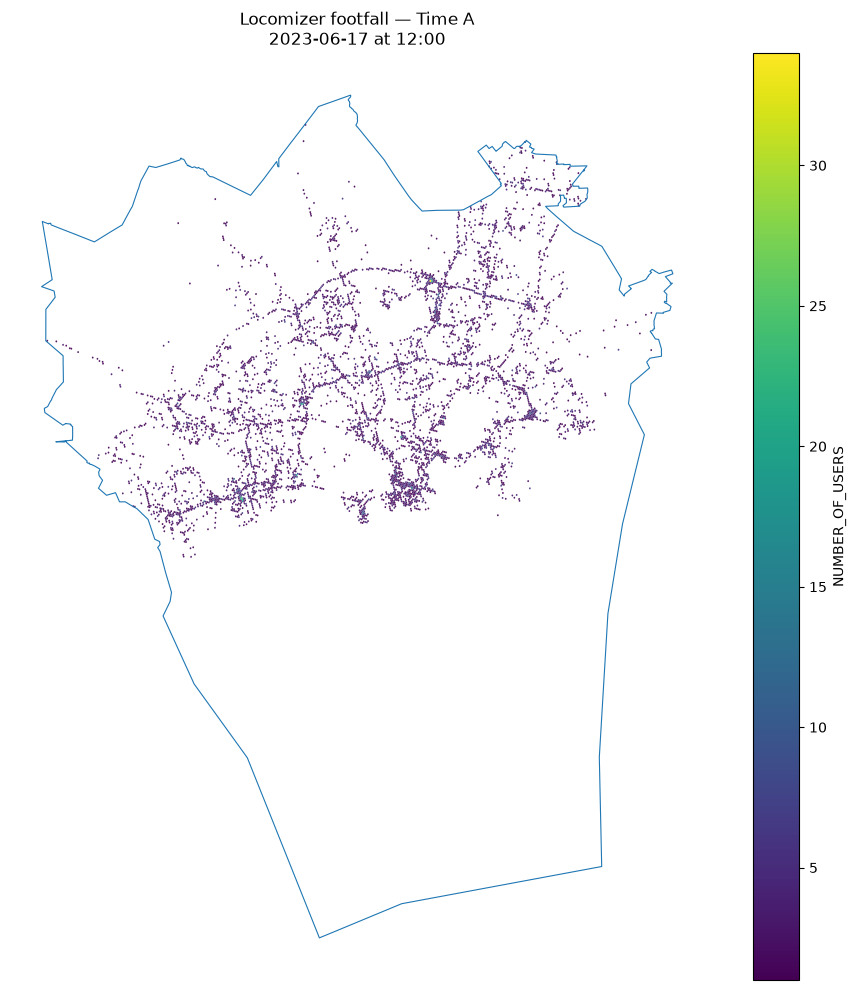

In [7]:
fig, ax = plt.subplots(figsize=(10, 10))

hma_boundary.boundary.plot(
    ax=ax,
    linewidth=0.8,
)

comparison_gdf.plot(
    ax=ax,
    column="footfall_A",
    legend=True,
    linewidth=0,
    alpha=0.9,
    legend_kwds={"label": "NUMBER_OF_USERS"},
)

ax.set_title(
    f"Locomizer footfall — Time A\n"
    f"{TIME_A_DATE.date()} at {TIME_A_HOUR:02d}:00"
)
ax.set_axis_off()

plt.tight_layout()
plt.show()


## 8. Map footfall at Time B

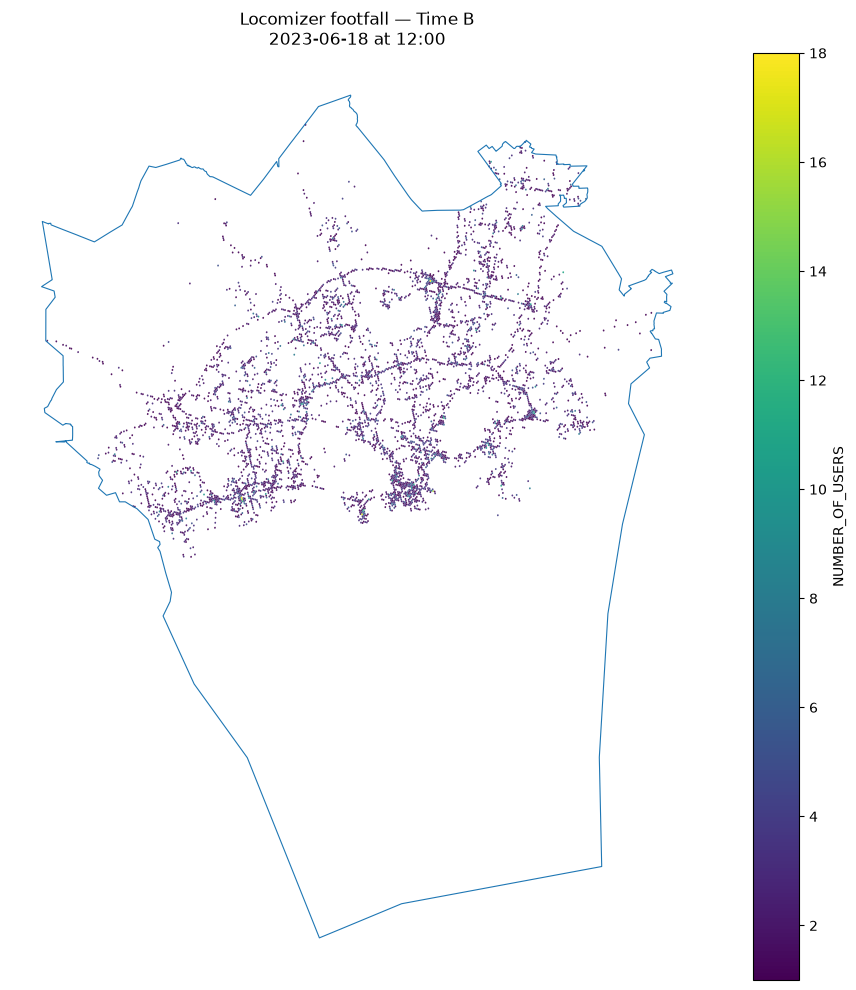

In [8]:
fig, ax = plt.subplots(figsize=(10, 10))

hma_boundary.boundary.plot(
    ax=ax,
    linewidth=0.8,
)

comparison_gdf.plot(
    ax=ax,
    column="footfall_B",
    legend=True,
    linewidth=0,
    alpha=0.9,
    legend_kwds={"label": "NUMBER_OF_USERS"},
)

ax.set_title(
    f"Locomizer footfall — Time B\n"
    f"{TIME_B_DATE.date()} at {TIME_B_HOUR:02d}:00"
)
ax.set_axis_off()

plt.tight_layout()
plt.show()


## 9. Map percentage footfall change from A → B

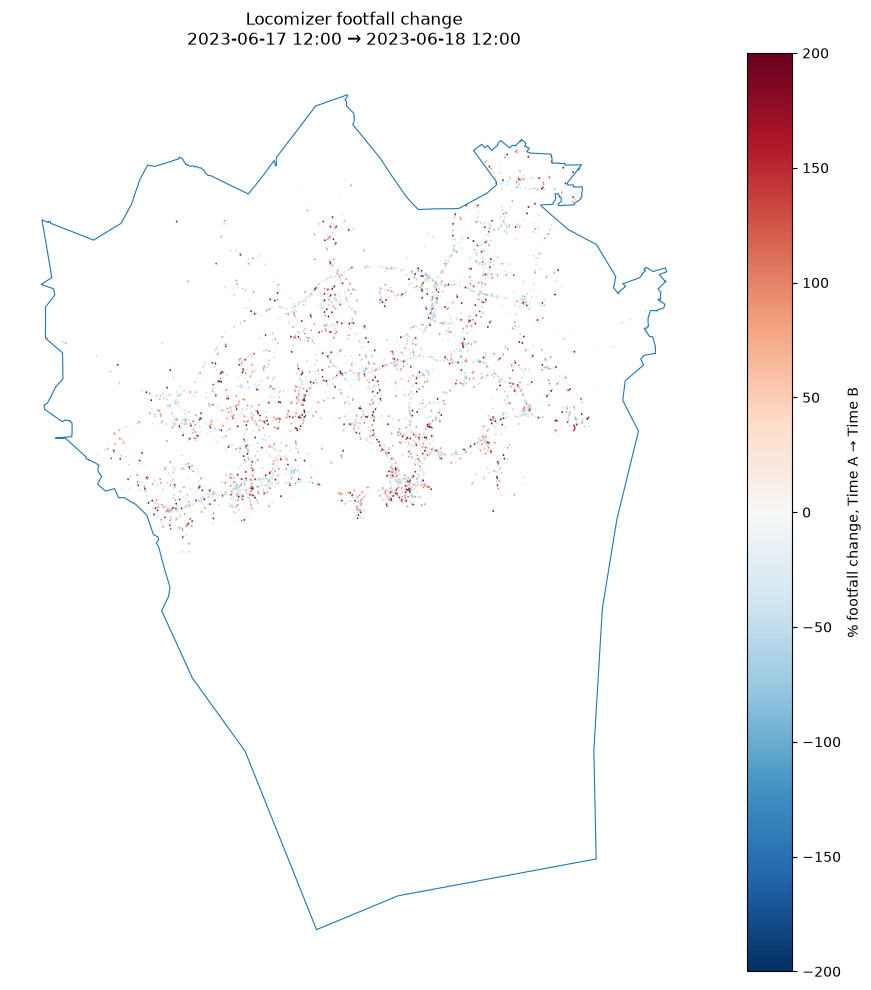

In [9]:
plot_change = comparison_gdf.dropna(
    subset=["pct_change_footfall"]
).copy()

limit = np.nanpercentile(
    np.abs(plot_change["pct_change_footfall"]),
    95,
)

if not np.isfinite(limit) or limit == 0:
    limit = 1

fig, ax = plt.subplots(figsize=(10, 10))

hma_boundary.boundary.plot(
    ax=ax,
    linewidth=0.8,
)

plot_change.plot(
    ax=ax,
    column="pct_change_footfall",
    cmap="RdBu_r",
    vmin=-limit,
    vmax=limit,
    legend=True,
    linewidth=0,
    alpha=0.9,
    legend_kwds={"label": "% footfall change, Time A → Time B"},
)

ax.set_title(
    "Locomizer footfall change\n"
    f"{TIME_A_DATE.date()} {TIME_A_HOUR:02d}:00 → "
    f"{TIME_B_DATE.date()} {TIME_B_HOUR:02d}:00"
)
ax.set_axis_off()

plt.tight_layout()
plt.show()


## 10. Optional: attach temporally matched PM₂.₅ rasters

This block is intentionally disabled until you supply PM₂.₅ rasters corresponding to **Time A** and **Time B**.

The raster value is sampled at the H3 cell centroid.

For the paper, document:

- PM₂.₅ data source;
- timestamp / averaging interval;
- spatial resolution;
- units;
- any missing-data handling.


In [10]:
def sample_raster_at_h3_centroids(
    gdf,
    raster_path,
    band=1,
    output_col="pm25",
):
    result = gdf.copy()

    with rasterio.open(raster_path) as src:
        centroids = result.to_crs(src.crs).geometry.centroid
        coords = [(geom.x, geom.y) for geom in centroids]

        values = list(
            src.sample(
                coords,
                indexes=band,
                masked=True,
            )
        )

        sampled = []

        for value in values:
            v = value[0]

            if np.ma.is_masked(v):
                sampled.append(np.nan)
            else:
                sampled.append(float(v))

        result[output_col] = sampled

    return result


if PM25_A_PATH is not None and PM25_B_PATH is not None:
    comparison_gdf = sample_raster_at_h3_centroids(
        comparison_gdf,
        PM25_A_PATH,
        band=PM25_A_BAND,
        output_col="pm25_A",
    )

    comparison_gdf = sample_raster_at_h3_centroids(
        comparison_gdf,
        PM25_B_PATH,
        band=PM25_B_BAND,
        output_col="pm25_B",
    )

    comparison_gdf["delta_pm25"] = (
        comparison_gdf["pm25_B"]
        - comparison_gdf["pm25_A"]
    )

    print("PM2.5 attached.")
else:
    comparison_gdf["pm25_A"] = np.nan
    comparison_gdf["pm25_B"] = np.nan
    comparison_gdf["delta_pm25"] = np.nan

    print(
        "PM2.5 integration skipped: "
        "set PM25_A_PATH and PM25_B_PATH to temporally matched rasters."
    )


PM2.5 integration skipped: set PM25_A_PATH and PM25_B_PATH to temporally matched rasters.


## 11. Simple response classification

This classification is descriptive rather than causal.

When PM₂.₅ is available, cells are grouped as:

- **possible avoidance** — PM₂.₅ increased and footfall decreased;
- **persistent activity** — PM₂.₅ increased while footfall changed little;
- **increased activity despite poorer air** — PM₂.₅ increased and footfall increased;
- **other / mixed** — remaining combinations.

The footfall "little change" threshold below is ±5%. Adjust it later as part of sensitivity analysis.


In [11]:
FOOTFALL_STABLE_THRESHOLD_PCT = 5.0

def classify_response(row):
    if pd.isna(row["delta_pm25"]):
        if row["pct_change_footfall"] < -FOOTFALL_STABLE_THRESHOLD_PCT:
            return "footfall decreased (PM2.5 unavailable)"
        elif row["pct_change_footfall"] > FOOTFALL_STABLE_THRESHOLD_PCT:
            return "footfall increased (PM2.5 unavailable)"
        else:
            return "footfall broadly stable (PM2.5 unavailable)"

    if row["delta_pm25"] > 0:
        if row["pct_change_footfall"] < -FOOTFALL_STABLE_THRESHOLD_PCT:
            return "possible avoidance"
        elif row["pct_change_footfall"] > FOOTFALL_STABLE_THRESHOLD_PCT:
            return "increased activity despite poorer air"
        else:
            return "persistent activity"

    return "other / mixed"

comparison_gdf["response_class"] = comparison_gdf.apply(
    classify_response,
    axis=1,
)

comparison_gdf["response_class"].value_counts(dropna=False)


response_class
footfall decreased (PM2.5 unavailable)         1666
footfall broadly stable (PM2.5 unavailable)    1619
footfall increased (PM2.5 unavailable)         1588
Name: count, dtype: int64

## 12. Map response classes

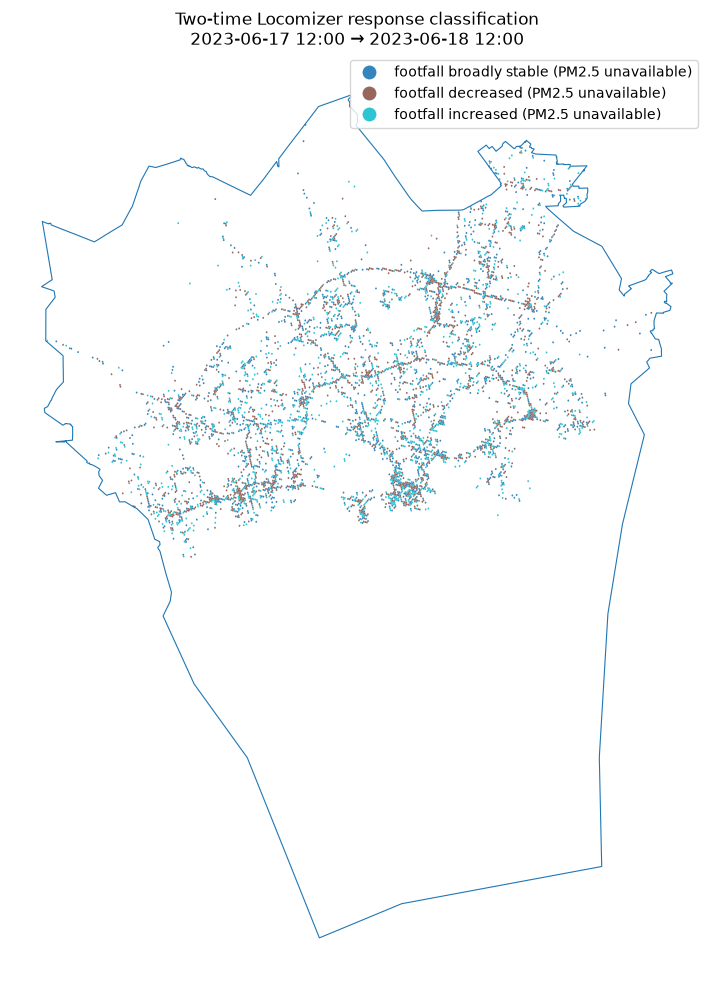

In [12]:
fig, ax = plt.subplots(figsize=(11, 10))

hma_boundary.boundary.plot(
    ax=ax,
    linewidth=0.8,
)

comparison_gdf.plot(
    ax=ax,
    column="response_class",
    categorical=True,
    legend=True,
    linewidth=0,
    alpha=0.9,
)

ax.set_title(
    "Two-time Locomizer response classification\n"
    f"{TIME_A_DATE.date()} {TIME_A_HOUR:02d}:00 → "
    f"{TIME_B_DATE.date()} {TIME_B_HOUR:02d}:00"
)
ax.set_axis_off()

plt.tight_layout()
plt.show()


## 13. Optional PM₂.₅ vs footfall-change scatterplot

This becomes useful once temporally matched PM₂.₅ values are attached.


In [13]:
scatter = comparison_gdf.dropna(
    subset=["delta_pm25", "pct_change_footfall"]
).copy()

if scatter.empty:
    print(
        "No temporally matched PM2.5 values yet, "
        "so the PM2.5 / footfall-change scatterplot is skipped."
    )
else:
    fig, ax = plt.subplots(figsize=(8, 6))

    ax.scatter(
        scatter["delta_pm25"],
        scatter["pct_change_footfall"],
        alpha=0.5,
    )

    ax.axhline(0, linewidth=0.8)
    ax.axvline(0, linewidth=0.8)

    ax.set_xlabel("Change in PM2.5 (Time B - Time A)")
    ax.set_ylabel("% change in footfall")
    ax.set_title("PM2.5 change vs Locomizer footfall response")

    plt.tight_layout()
    plt.show()


No temporally matched PM2.5 values yet, so the PM2.5 / footfall-change scatterplot is skipped.


## 14. Regional summary

The sums below are sums of **cell-level `NUMBER_OF_USERS`**. They must not be described as counts of unique people.


In [14]:
summary = pd.DataFrame(
    {
        "metric": [
            "cells compared",
            "summed cell users — Time A",
            "summed cell users — Time B",
            "change in summed cell users",
            "% change in summed cell users",
        ],
        "value": [
            len(comparison_gdf),
            comparison_gdf["footfall_A"].sum(),
            comparison_gdf["footfall_B"].sum(),
            comparison_gdf["delta_footfall"].sum(),
            (
                100
                * (
                    comparison_gdf["footfall_B"].sum()
                    - comparison_gdf["footfall_A"].sum()
                )
                / comparison_gdf["footfall_A"].sum()
                if comparison_gdf["footfall_A"].sum() > 0
                else np.nan
            ),
        ],
    }
)

display(summary)


,metric,value
0,cells compared,4873.000000
1,summed cell users — Time A,11756.000000
2,summed cell users — Time B,11504.000000
3,change in summed cell users,-252.000000
4,% change in summed cell users,-2.143586


## 15. Save outputs

In [15]:
csv_path = OUTPUT_DIR / "locomizer_two_time_change.csv"
gpkg_path = OUTPUT_DIR / "locomizer_two_time_change.gpkg"
summary_path = OUTPUT_DIR / "locomizer_two_time_summary.csv"

comparison_gdf.drop(columns="geometry").to_csv(
    csv_path,
    index=False,
)

comparison_gdf.to_file(
    gpkg_path,
    layer="h3_change",
    driver="GPKG",
)

summary.to_csv(
    summary_path,
    index=False,
)

print("Saved:", csv_path)
print("Saved:", gpkg_path)
print("Saved:", summary_path)


Saved: ../outputs/v2/05_locomizer_two_time_pm25_change/locomizer_two_time_change.csv
Saved: ../outputs/v2/05_locomizer_two_time_pm25_change/locomizer_two_time_change.gpkg
Saved: ../outputs/v2/05_locomizer_two_time_pm25_change/locomizer_two_time_summary.csv


## 16. How this connects to the CAFEIN workflow

This notebook measures **observed spatial activity response**.

The CAFEIN notebooks measure **potential route-based environmental exposure and route alternatives**.

The next integration can therefore join neighbourhood-level summaries from this H3 analysis to CAFEIN results, for example:

| neighbourhood | observed footfall change | route PM₂.₅ | lower-exposure alternative | extra travel time |
|---|---:|---:|---:|---:|

That supports the larger question:

> Where does activity persist during poorer environmental conditions, and where do people have realistic lower-exposure mobility alternatives?

Do **not** interpret Locomizer cells as individual trajectories. They provide cell-level presence / footfall, while CAFEIN provides plausible route and accessibility conditions.
